In [58]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

In [47]:
df = pd.read_csv('/media/prince/5A4E832F4E83034D/Fraud-Detector-ML/Data/Fraud_Data.csv')

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588912 entries, 0 to 588911
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   transaction_id           588912 non-null  int64  
 1   is_fraud                 588912 non-null  int64  
 2   transaction_time         588912 non-null  int64  
 3   transaction_amount       588912 non-null  float64
 4   card_network             588912 non-null  object 
 5   card_type                588912 non-null  object 
 6   purchaser_email_domain   494686 non-null  object 
 7   device_type              140606 non-null  object 
 8   is_identity_seen_before  129173 non-null  object 
 9   user_os                  144028 non-null  object 
 10  user_browser             144028 non-null  object 
 11  environment              144028 non-null  object 
 12  environment_freq         144028 non-null  float64
 13  environment_risk         144028 non-null  float64
 14  devi

In [49]:
df = df.drop(columns=['device_os_invalid'])

In [50]:
df['transaction_time']

0            86400
1            86401
2            86469
3            86499
4            86506
            ...   
588907    15811047
588908    15811049
588909    15811079
588910    15811088
588911    15811131
Name: transaction_time, Length: 588912, dtype: int64

In [51]:
df['transaction_time'].max()

15811131

In [52]:
df['time_hour'] = (df['transaction_time'] // 3600) % 24
df['time_day']  = df['transaction_time'] / 86400
df['time_diff'] = df['transaction_time'].diff()
df['time_diff_min'] = df['time_diff'] / 60

In [53]:
df[['time_day', 'time_hour', 'time_diff_min']]

,time_day,time_hour,time_diff_min
0,1.000000,0,NaN
1,1.000012,0,0.016667
2,1.000799,0,1.133333
3,1.001146,0,0.500000
4,1.001227,0,0.116667
...,...,...,...
588907,182.998229,23,0.283333
588908,182.998252,23,0.033333
588909,182.998600,23,0.500000
588910,182.998704,23,0.150000


In [56]:
df['time_diff_min'].min()

0.0

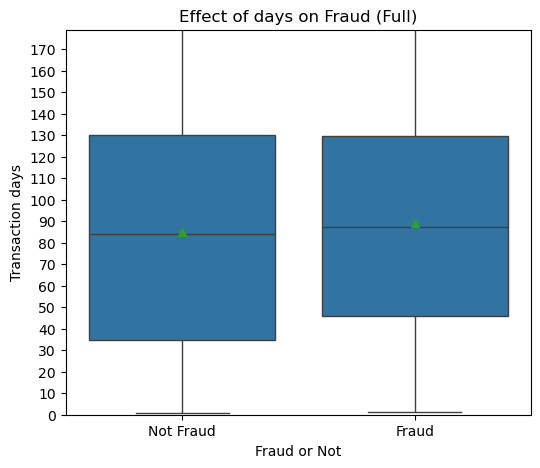

In [63]:
def plot_fraud_box(df, ylim=None, yticks=None, title_suffix="Full"):
    plt.figure(figsize=(6, 5))

    sns.boxplot(
        data=df,
        x='is_fraud',
        y='time_day',
        showmeans=True
    )

    plt.xticks([0, 1], ['Not Fraud', 'Fraud'])
    plt.xlabel('Fraud or Not')
    plt.ylabel('Transaction days')
    plt.title(f'Effect of days on Fraud ({title_suffix})')

    if ylim:
        plt.ylim(0, ylim)
    if yticks and ylim:
        plt.yticks(range(0, ylim + 1, yticks))

    plt.show()

plot_fraud_box(df, ylim=179, yticks=10)

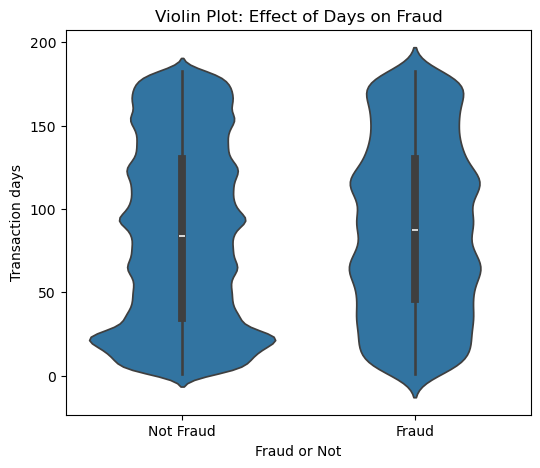

In [64]:
plt.figure(figsize=(6, 5))

sns.violinplot(
    data=df,
    x='is_fraud',
    y='time_day'
)

plt.xticks([0, 1], ['Not Fraud', 'Fraud'])
plt.xlabel('Fraud or Not')
plt.ylabel('Transaction days')
plt.title('Violin Plot: Effect of Days on Fraud')
plt.show()

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588912 entries, 0 to 588911
Data columns (total 19 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   transaction_id           588912 non-null  int64  
 1   is_fraud                 588912 non-null  int64  
 2   transaction_time         588912 non-null  int64  
 3   transaction_amount       588912 non-null  float64
 4   card_network             588912 non-null  object 
 5   card_type                588912 non-null  object 
 6   purchaser_email_domain   494686 non-null  object 
 7   device_type              140606 non-null  object 
 8   is_identity_seen_before  129173 non-null  object 
 9   user_os                  144028 non-null  object 
 10  user_browser             144028 non-null  object 
 11  environment              144028 non-null  object 
 12  environment_freq         144028 non-null  float64
 13  environment_risk         144028 non-null  float64
 14  card